In [2]:
import illustris_python as il
import matplotlib.pyplot as plt
import h5py
import numpy as np
import sys
sys.path.append('../../py_files/')
import control_sample as control
import BRAHMA_python as il_brahma
from tqdm import tqdm
import host_galaxy_enhancement_plots as hostplot

In [3]:
import host_utils as hostutils

In [4]:
import scienceplots
plt.style.use(['science'])
import os
tex_path = '/apps/texlive/2023/bin/x86_64-linux/'
os.environ['PATH'] += os.pathsep + tex_path

In [5]:
pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/' 
tng_pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/'

TNG_basepath = '/orange/lblecha/IllustrisTNG/Runs/TNG50-1/output'
TNG_50_pop = control.load_pop_file(TNG_basepath,tng_pop_file_path,[0,0,1000,1])
TNG_color = '#d95f02'

In [6]:
brahma_basepath="/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/"
brahma_simName_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_TNG','SM5_LW10_LOWSPIN_RICH_TNG']
brahma_sim_colors = {
    brahma_simName_array[0]: '#bdc9e1', 
    brahma_simName_array[1]: '#67a9cf', 
    brahma_simName_array[2]: '#1c9099', 
    brahma_simName_array[3]: '#016c59',
    brahma_simName_array[4]: '#3690c0',
    brahma_simName_array[5]: '#02818a'
}
brahma_sim_pop = {}
#brahma_sim_zbins = {}
#brahma_sim_zbin_width = {}
for i,sim in enumerate(brahma_simName_array):
    simPath = brahma_basepath + sim + '/'
    brahma_pop_Nstar10 = control.load_pop_file(simPath,pop_file_path,[10,10,10,1])
    brahma_sim_pop[sim] = brahma_pop_Nstar10

In [7]:
brahma_sim_pop['SM5_TNG']['merging_population'].keys()

<KeysViewHDF5 ['MBH', 'MBH_luminous', 'MBH_massive', 'Mdot', 'Mdot_luminous', 'Mdot_massive', 'Mgas', 'MgasInRad', 'Mstar', 'MstarInRad', 'Msubhalo', 'SFR', 'StellarHalfmassRad', 'SubhaloLenType', 'SubhaloPhotoMag', 'prog_MBH', 'prog_Mdot', 'prog_Mgas', 'prog_MgasInRad', 'prog_Mstar', 'prog_MstarInRad', 'prog_SFR', 'prog_StellarHalfmassRad', 'prog_redshift', 'prog_snap', 'prog_subhalo_id', 'q_merger', 'snap', 'subhalo_ids', 'z']>

In [8]:
TNG_50_pop["merging_population"].keys()

<KeysViewHDF5 ['MBH', 'Mdot', 'Mgas', 'MgasInRad', 'Mstar', 'MstarInRad', 'Msubhalo', 'SFR', 'StellarHalfmassRad', 'SubhaloLenType', 'SubhaloPhotoMag', 'prog_MBH', 'prog_Mdot', 'prog_Mgas', 'prog_MgasInRad', 'prog_Mstar', 'prog_MstarInRad', 'prog_SFR', 'prog_StellarHalfmassRad', 'prog_redshift', 'prog_snap', 'prog_subhalo_id', 'q_merger', 'snap', 'subhalo_ids', 'z']>

In [9]:
linestyles = ['solid', 'dashed', 'dotted', 'dashdot', '--', ':']


In [10]:
np.max(np.log10(TNG_50_pop["merging_population"]['q_merger'][:]))

-0.009906661431504232

/tmp/ipykernel_1416568/1791773465.py:25: RuntimeWarning: divide by zero encountered in log10
  N_MBH_brahma,_ = np.histogram(np.log10(brahma_sim_pop[sim]["merging_population"]['MBH'][:]),bins=MBH_bins)
/tmp/ipykernel_1416568/1791773465.py:26: RuntimeWarning: divide by zero encountered in log10
  axes[1,0].hist(np.log10(brahma_sim_pop[sim]["merging_population"]['MBH'][:]),bins=MBH_bins,label=sim,histtype="step",color=brahma_sim_colors[sim],linewidth=2,linestyle=ls)
/tmp/ipykernel_1416568/1791773465.py:27: RuntimeWarning: divide by zero encountered in log10
  N_MBH_TNG,_ = np.histogram(np.log10(TNG_50_pop["merging_population"]['MBH'][:]),bins=MBH_bins)
/tmp/ipykernel_1416568/1791773465.py:28: RuntimeWarning: divide by zero encountered in log10
  axes[1,0].hist(np.log10(TNG_50_pop["merging_population"]['MBH'][:]),bins=MBH_bins,label='TNG50-1',histtype="step",color=TNG_color,linewidth=2)


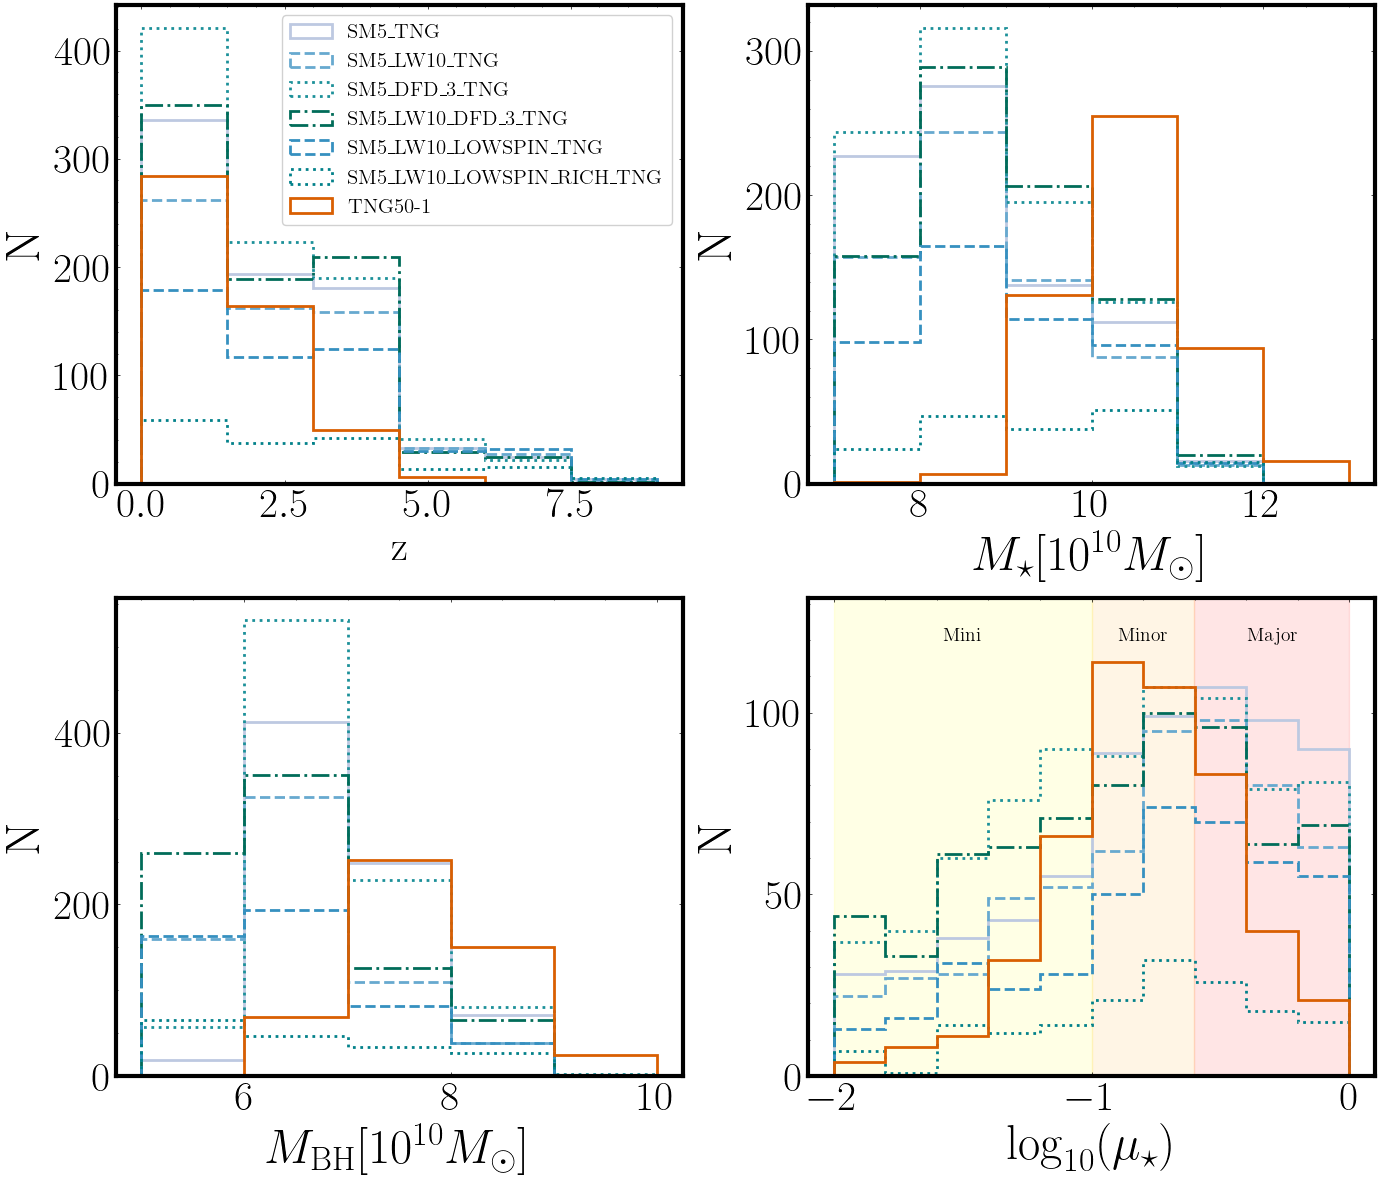

In [11]:
hostplot.set_plot_style(spinewidth=3,linewidth=3, titlesize=30,labelsize=35,xlabelsize=30,ylabelsize=30,legendsize=15,bold=True)
z_bins = np.arange(0,10,1.5)
fig,axes = plt.subplots(2,2,figsize=(14,12),sharey=False)

for sim, ls in zip(brahma_simName_array, linestyles):
    Nz_brahma,_ = np.histogram(brahma_sim_pop[sim]["merging_population"]['z'][:],bins=z_bins)
    axes[0,0].hist(brahma_sim_pop[sim]["merging_population"]['z'][:],bins=z_bins,label=sim,histtype="step",
                   color=brahma_sim_colors[sim],linewidth=2,linestyle=ls)

Nz_TNG,_ = np.histogram(TNG_50_pop["merging_population"]['z'][:],bins=z_bins)
axes[0,0].hist(TNG_50_pop["merging_population"]['z'][:],bins=z_bins,label='TNG50-1',histtype="step",color=TNG_color,linewidth=2)

axes[0,0].set_xlabel('z',fontsize=30)
axes[0,0].set_ylabel('N')
axes[0,0].legend()
#add box to the legend with transparent background
legend = axes[0,0].legend(frameon=True)
frame = legend.get_frame()
frame.set_alpha(0.9)
# axes[0].step((z_bins[:-1]+z_bins[1:])/2,Nz_TNG,where='post',label='TNG50-1',color='black')

MBH_bins = np.arange(5,11,1)

for sim, ls in zip(brahma_simName_array, linestyles):
    N_MBH_brahma,_ = np.histogram(np.log10(brahma_sim_pop[sim]["merging_population"]['MBH'][:]),bins=MBH_bins)
    axes[1,0].hist(np.log10(brahma_sim_pop[sim]["merging_population"]['MBH'][:]),bins=MBH_bins,label=sim,histtype="step",color=brahma_sim_colors[sim],linewidth=2,linestyle=ls)
N_MBH_TNG,_ = np.histogram(np.log10(TNG_50_pop["merging_population"]['MBH'][:]),bins=MBH_bins)
axes[1,0].hist(np.log10(TNG_50_pop["merging_population"]['MBH'][:]),bins=MBH_bins,label='TNG50-1',histtype="step",color=TNG_color,linewidth=2)
axes[1,0].set_xlabel(r'$M_{\rm BH}[10^{10} M_{\odot}]$')
axes[1,0].set_ylabel('N')
Mstar_bins = np.arange(7,14,1)

for sim, ls in zip(brahma_simName_array, linestyles):
    N_Mstar_brahma,_ = np.histogram(np.log10(brahma_sim_pop[sim]["merging_population"]['Mstar'][:]),bins=Mstar_bins)
    axes[0,1].hist(np.log10(brahma_sim_pop[sim]["merging_population"]['Mstar'][:]),bins=Mstar_bins,label=sim,histtype="step",color=brahma_sim_colors[sim],linewidth=2,linestyle=ls)
N_Mstar_TNG,_ = np.histogram(np.log10(TNG_50_pop["merging_population"]['Mstar'][:]),bins=Mstar_bins)
axes[0,1].hist(np.log10(TNG_50_pop["merging_population"]['Mstar'][:]),bins=Mstar_bins,label='TNG50-1',histtype="step",color=TNG_color,linewidth=2)
axes[0,1].set_xlabel(r'$M_{\star}[10^{10} M_{\odot}]$') 
axes[0,1].set_ylabel('N')

mu_bins = np.arange(-2,0.1,0.2)
for sim, ls in zip(brahma_simName_array, linestyles):
    N_mu_brahma,_ = np.histogram(np.log10(brahma_sim_pop[sim]["merging_population"]['q_merger'][:]),bins=mu_bins)
    axes[1,1].hist(np.log10(brahma_sim_pop[sim]["merging_population"]['q_merger'][:]),bins=mu_bins,label=sim,histtype="step",color=brahma_sim_colors[sim],linewidth=2,linestyle=ls)

N_mu_TNG,_ = np.histogram(np.log10(TNG_50_pop["merging_population"]['q_merger'][:]),bins=mu_bins)
axes[1,1].hist(np.log10(TNG_50_pop["merging_population"]['q_merger'][:]),bins=mu_bins,label='TNG50-1',histtype="step",color=TNG_color,linewidth=2)
# Add shaded regions for merger types
axes[1,1].axvspan(np.log10(0.25), 0, alpha=0.1, color='red', label='Major (μ>0.25)')
axes[1,1].axvspan(np.log10(0.1), np.log10(0.25), alpha=0.1, color='orange', label='Minor (0.1<μ<0.25)')
axes[1,1].axvspan(-2, np.log10(0.1), alpha=0.1, color='yellow', label='Mini (μ<0.1)')

# Add text labels for each region
y_pos = axes[1,1].get_ylim()[1]  # Position text at 85% of y-axis height
axes[1,1].text(-0.3, y_pos, 'Major', fontsize=14, ha='center', weight='bold')
axes[1,1].text(-0.8, y_pos, 'Minor', fontsize=14, ha='center', weight='bold')
axes[1,1].text(-1.5, y_pos, 'Mini', fontsize=14, ha='center', weight='bold')


axes[1,1].set_xlabel(r'$\log_{10}(\mu_{\star})$')
axes[1,1].set_ylabel('N')
axes[1,1].set_ylim(0, axes[1,1].get_ylim()[1]*1.1)
fig.tight_layout()
fig.savefig('../../figures/merging_population_comparison_TNG50_BRAHMA_Nstar10.pdf')

/tmp/ipykernel_1416568/207914343.py:8: RuntimeWarning: divide by zero encountered in log10
  N_MBH_brahma,_ = np.histogram(np.log10(brahma_sim_pop[sim]["merging_population"]['MBH'][:]),bins=MBH_bins)
/tmp/ipykernel_1416568/207914343.py:9: RuntimeWarning: divide by zero encountered in log10
  ax.hist(np.log10(brahma_sim_pop[sim]["merging_population"]['MBH'][:]),bins=MBH_bins,label=sim,histtype="step",color=brahma_sim_colors[sim],linewidth=3)
/tmp/ipykernel_1416568/207914343.py:10: RuntimeWarning: divide by zero encountered in log10
  N_MBH_TNG,_ = np.histogram(np.log10(TNG_50_pop["merging_population"]['MBH'][:]),bins=MBH_bins)
/tmp/ipykernel_1416568/207914343.py:11: RuntimeWarning: divide by zero encountered in log10
  ax.hist(np.log10(TNG_50_pop["merging_population"]['MBH'][:]),bins=MBH_bins,label='TNG50-1',histtype="step",color=TNG_color,linewidth=3)


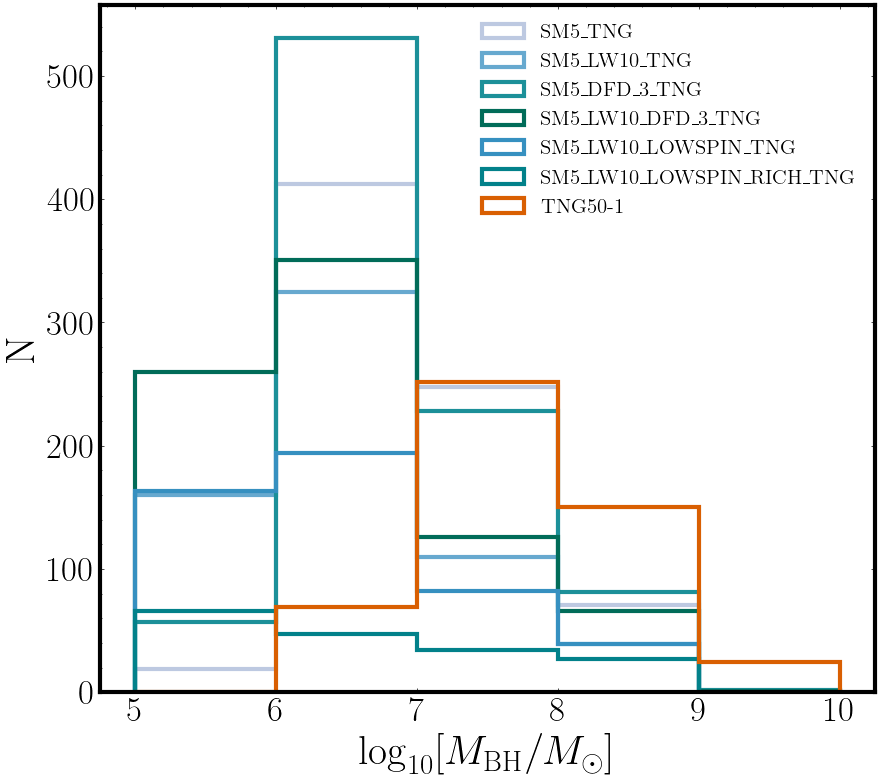

In [12]:
hostplot.set_plot_style(spinewidth=3,linewidth=3, titlesize=30,labelsize=30,xlabelsize=25,ylabelsize=25,legendsize=15,bold=True)

fig,ax = plt.subplots(1,1,figsize=(9,8))

MBH_bins = np.arange(5,11,1)

for sim in brahma_simName_array:
    N_MBH_brahma,_ = np.histogram(np.log10(brahma_sim_pop[sim]["merging_population"]['MBH'][:]),bins=MBH_bins)
    ax.hist(np.log10(brahma_sim_pop[sim]["merging_population"]['MBH'][:]),bins=MBH_bins,label=sim,histtype="step",color=brahma_sim_colors[sim],linewidth=3)
N_MBH_TNG,_ = np.histogram(np.log10(TNG_50_pop["merging_population"]['MBH'][:]),bins=MBH_bins)
ax.hist(np.log10(TNG_50_pop["merging_population"]['MBH'][:]),bins=MBH_bins,label='TNG50-1',histtype="step",color=TNG_color,linewidth=3)
ax.set_xlabel(r'$ \log_{10}[M_{\rm BH}/M_{\odot}]$')
ax.set_ylabel('N')
ax.legend()
fig.tight_layout()
#fig.savefig('../figures/BH_population_TNG50_BRAHMA.pdf')

## Merger hosts versus all subhalos

In [13]:
TNG50_all_subhalos_file_loc = "/home/pranavsatheesh/host_galaxies/data/TNG-50_subhalo_statistics.hdf5"
TNG50_all_subhalos = h5py.File(TNG50_all_subhalos_file_loc)

brahma_all_subhalos  = {}
#brahma_sim_zbins = {}
#brahma_sim_zbin_width = {}
for i,sim in enumerate(brahma_simName_array):
    sim_file_loc = f"/home/pranavsatheesh/host_galaxies/data/{sim}_subhalo_statistics.hdf5"
    brahma_all_subhalos[sim] = h5py.File(sim_file_loc)

sim_names = brahma_simName_array + ['TNG50']
sim_colors = [brahma_sim_colors[sim] for sim in brahma_simName_array] + [TNG_color]
sim_all_subhalos = brahma_all_subhalos
sim_all_subhalos['TNG50'] = TNG50_all_subhalos
sim_zbins_list = [np.arange(0,10,1) for _ in brahma_simName_array] + [np.arange(0,6,1)]

In [14]:
simName_array = ['TNG50','SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_TNG','SM5_LW10_LOWSPIN_RICH_TNG']
all_subhalos_objs = {}

for sim in simName_array:
    subhalo_file = "/home/pranavsatheesh/host_galaxies/data/" + sim + "_subhalo_statistics.hdf5"
    all_subhalos_objs[sim] = h5py.File(subhalo_file,'r')

In [15]:
all_subhalos_objs['TNG50'].keys()

<KeysViewHDF5 ['MBH', 'MdotBH', 'MgasinRad', 'Mgastotal', 'Mstar', 'MstarinRad', 'SFR', 'StellarHalfmassRadType', 'SubhaloPhotoMag', 'snap', 'z']>

In [16]:
all_sim_objs = {}
sim_colors = {}


TNG_50_control = control.control_samples_TNG(TNG_50_pop,max_Mstar_tolerance=0.15,max_z_tolerance=0.1)
TNG_color = '#d95f02'
all_sim_objs['TNG50'] = TNG_50_control
sim_colors['TNG50'] = TNG_color

brahma_basepath="/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/"
brahma_simName_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_TNG','SM5_LW10_LOWSPIN_RICH_TNG']

brahma_sim_colors = {
    brahma_simName_array[0]: '#bdc9e1', 
    brahma_simName_array[1]: '#67a9cf', 
    brahma_simName_array[2]: '#1c9099', 
    brahma_simName_array[3]: '#016c59',
    brahma_simName_array[4]: '#3690c0',
    brahma_simName_array[5]: '#02818a'
}

for i,sim in enumerate(brahma_simName_array):
    simPath = brahma_basepath + sim + '/'
    brahma_pop_Nstar10 = control.load_pop_file(simPath,pop_file_path,[10,10,10,1])
    if brahma_simName_array[i] == 'SM5_LW10_LOWSPIN_RICH_TNG':
        brahma_control = control.control_sample_brahma(brahma_pop_Nstar10,max_Mstar_tolerance=0.6,max_z_tolerance=0.2)
    else:
        brahma_control = control.control_sample_brahma(brahma_pop_Nstar10,max_Mstar_tolerance=0.15,max_z_tolerance=0.2)
    all_sim_objs[sim] = brahma_control
    sim_colors[sim] = brahma_sim_colors[sim]



finding controls:   0%|          | 0/504 [00:00<?, ?it/s]

finding controls: 100%|██████████| 504/504 [00:04<00:00, 125.02it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:398: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


Number of available mergers in this population is 504
Number of cases where a close enough match is not found within the acceptable tolerance: 16


finding controls: 100%|██████████| 773/773 [00:00<00:00, 27163.41it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:691: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:695: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_massive_pop = self.Mdot_massive_control_pop/self.MBH_massive_control_pop
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:698: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_luminous_pop = self.Mdot_luminous_control_pop/self.MBH_luminous_control_pop


Number of cases where a close enough match is not found within the acceptable tolerance: 172
number of processable mergers with valid controls:
581


...

Number of cases where a close enough match is not found within the acceptable tolerance: 228
number of processable mergers with valid controls:
574


finding controls: 100%|██████████| 488/488 [00:00<00:00, 27373.06it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 123
number of processable mergers with valid controls:
356


finding controls: 100%|██████████| 175/175 [00:00<00:00, 25583.05it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 25
number of processable mergers with valid controls:
149


In [17]:
def plot_property_vs_Mstar_for_z_interval_for_all_subhalos(ax,sim_obj,sim_name,sim_color,z_lower,z_upper,quantity_name
                                          ,plot_log10=True,alpha=0.1,size=5,marker='o',hist_bins=20,specific=False):
    #select mergers in the z interval
    #h=0.6774
    z_mask = (sim_obj['z'][:]>= z_lower) & (sim_obj['z'][:]< z_upper)
    Mstar_values = np.log10(sim_obj['Mstar'][z_mask])
    MBH_values = np.log10(sim_obj['MBH'][z_mask])

    if quantity_name == "sSFR":
        quantity_values = sim_obj['SFR'][z_mask]/sim_obj['Mstar'][z_mask]
    elif quantity_name == "sBHAR":
        quantity_values = sim_obj['MdotBH'][z_mask]/sim_obj['MBH'][z_mask]
    elif quantity_name == "fgas":
        quantity_values = sim_obj['MgasinRad'][z_mask]/(sim_obj['MgasinRad'][z_mask]+sim_obj['Mstar'][z_mask])
    else:
        quantity_values = sim_obj[quantity_name][z_mask]
    
    if plot_log10:
        quantity_values = np.log10(quantity_values)

    x = Mstar_values
    y = quantity_values
    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]
    H,xedges,yedges = np.histogram2d(x,y,bins=hist_bins,range=[[np.min(x), np.max(x)], [np.min(y), np.max(y)]])

    xcent = 0.5*(xedges[1:] + xedges[:-1])
    ycent = 0.5*(yedges[1:] + yedges[:-1])
    X,Y = np.meshgrid(xcent,ycent)
    flat = H.ravel()
    flat_nonzero = flat[flat > 0]
    perc = np.percentile(flat_nonzero,[50,68,90])

    ax.contour(X,Y,H.T,levels=perc,cmap='cividis',alpha=alpha)
    #ax.scatter(Mstar_values,quantity_values,color=sim_color,alpha=alpha,label="All subhalos",s=10,marker=marker)
    ax.set_xlabel(r'$M_{\star}$ [M$_{\odot}$]')
    return ax

In [18]:
def plot_property_vs_Mstar_for_z_interval(ax,sim_obj,sim_name,sim_color,z_lower,z_upper,quantity_name
                                          ,plot_log10=True,major_merger_mask=False,major_major_merger_mask=False,marker='o',size=20,alpha=1):
    #select mergers in the z interval
    if major_merger_mask:
        z_mergers = sim_obj.z_merging_pop[sim_obj.major_merger_mask]
        Mstar_mergers = sim_obj.Mstar_merging_pop[sim_obj.major_merger_mask]
        merger_mask = sim_obj.major_merger_mask
    elif major_major_merger_mask:
        z_mergers = sim_obj.z_merging_pop[sim_obj.major_major_merger_mask]
        Mstar_mergers = sim_obj.Mstar_merging_pop[sim_obj.major_major_merger_mask]
        merger_mask = sim_obj.major_major_merger_mask
    else:
        z_mergers = sim_obj.z_merging_pop
        Mstar_mergers = sim_obj.Mstar_merging_pop
        merger_mask = np.ones_like(z_mergers,dtype=bool)

    z_mask = (z_mergers >= z_lower) & (z_mergers < z_upper)
    Mstar_values = np.log10(Mstar_mergers[z_mask])

    if quantity_name == "StellarHalfmassRad_merging_pop":
        #convert ckpc to kpc by multipyling scale factor
        scale_factors = 1/(1+z_mergers[z_mask])
        stellar_halfmass_rad_kpc = sim_obj.StellarHalfmassRad_merging_pop[merger_mask][z_mask]*scale_factors
        quantity_values = stellar_halfmass_rad_kpc
    elif quantity_name == "fgas":
        quantity_values = sim_obj.fgas_post_merger[merger_mask][z_mask]
    else:
        quantity_values = getattr(sim_obj,quantity_name)[merger_mask][z_mask]
    if plot_log10:
        quantity_values = np.log10(quantity_values)
    #scatter plot
    ax.scatter(Mstar_values,quantity_values,color=sim_color,alpha=alpha,label=sim_name,s=size,marker=marker)
    ax.set_xlabel(r'$M_{\star}$ [M$_{\odot}$]')
    return ax

In [19]:
def plot_color_magnitude_diagram(ax,sim_obj,plot_name,sim_color,sim_alpha=1,sim_size=10,sim_marker='o'
                                 ,all_subhalos=True,scatter=True,contours=True,hist_bins=20
                                 ,z_lower=0,z_upper=2):


    if all_subhalos:
        z_mask = (sim_obj['z'][:]>= z_lower) & (sim_obj['z'][:]< z_upper)
        Mg = sim_obj['SubhaloPhotoMag'][z_mask,4] #g-band magnitude
        Mr = sim_obj['SubhaloPhotoMag'][z_mask,5] #r-band magnitude

        
    else:
        #considering only major major mergers (>0.25 mass ratio)
        z_mergers = sim_obj.z_merging_pop
        z_mask = (z_mergers >= z_lower) & (z_mergers < z_upper)
        major_major_merger_mask = sim_obj.major_major_merger_mask
        z_mask = z_mask & major_major_merger_mask
        Mg = sim_obj.SubhaloPhotoMag_merging_pop[z_mask,4]
        Mr = sim_obj.SubhaloPhotoMag_merging_pop[z_mask,5]
    
    if scatter:
        print(f"Plotting {len(Mg)} points for {plot_name}")
        
        ax.scatter(Mg-Mr,Mr,color=sim_color,alpha=sim_alpha,label=plot_name,s=sim_size,marker=sim_marker)

    if contours:
        x = Mg - Mr
        y = Mr
        valid = np.isfinite(x) & np.isfinite(y)
        x = x[valid]
        y = y[valid]
        H,xedges,yedges = np.histogram2d(x,y,bins=hist_bins,range=[[np.min(x), np.max(x)], [np.min(y), np.max(y)]])    
        xcent = 0.5*(xedges[1:] + xedges[:-1])
        ycent = 0.5*(yedges[1:] + yedges[:-1])
        X,Y = np.meshgrid(xcent,ycent)
        flat = H.ravel()
        flat_nonzero = flat[flat > 0]
        perc = np.percentile(flat_nonzero,[50,68,90])   
        ax.contour(X,Y,H.T,levels=perc,cmap='cividis',alpha=sim_alpha,label=plot_name)
        

    return ax

In [20]:
all_sim_objs['TNG50'].SubhaloPhotoMag_merging_pop

array([[-22.36887741, -21.76783371, -21.77435112, ..., -21.79280281,
        -21.74142838, -21.71417809],
       [-23.70079231, -23.14223862, -23.16781807, ..., -23.19657898,
        -23.17741013, -23.18655396],
       [-23.4203167 , -22.81738091, -22.82936096, ..., -22.85944557,
        -22.87733078, -22.93630219],
       ...,
       [-20.98563194, -20.9831562 , -21.55475426, ..., -21.80959892,
        -22.07330894, -22.27616501],
       [-18.97685242, -18.89035416, -19.35533333, ..., -19.56650543,
        -19.76767921, -19.91837502],
       [-21.995327  , -22.31627655, -23.07362175, ..., -23.38240433,
        -23.70620918, -23.95016479]])

Plotting sBHAR for subhalos and mergers...
Plotting sSFR for subhalos and mergers...


/tmp/ipykernel_1416568/2090530607.py:19: RuntimeWarning: divide by zero encountered in log10
  quantity_values = np.log10(quantity_values)


Plotting fgas for subhalos and mergers...


/tmp/ipykernel_1416568/1229949956.py:39: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(X,Y,H.T,levels=perc,cmap='cividis',alpha=sim_alpha,label=plot_name)


Plotting 136 points for Mergers
Plotting 40 points for Mergers
Plotting 21 points for Mergers


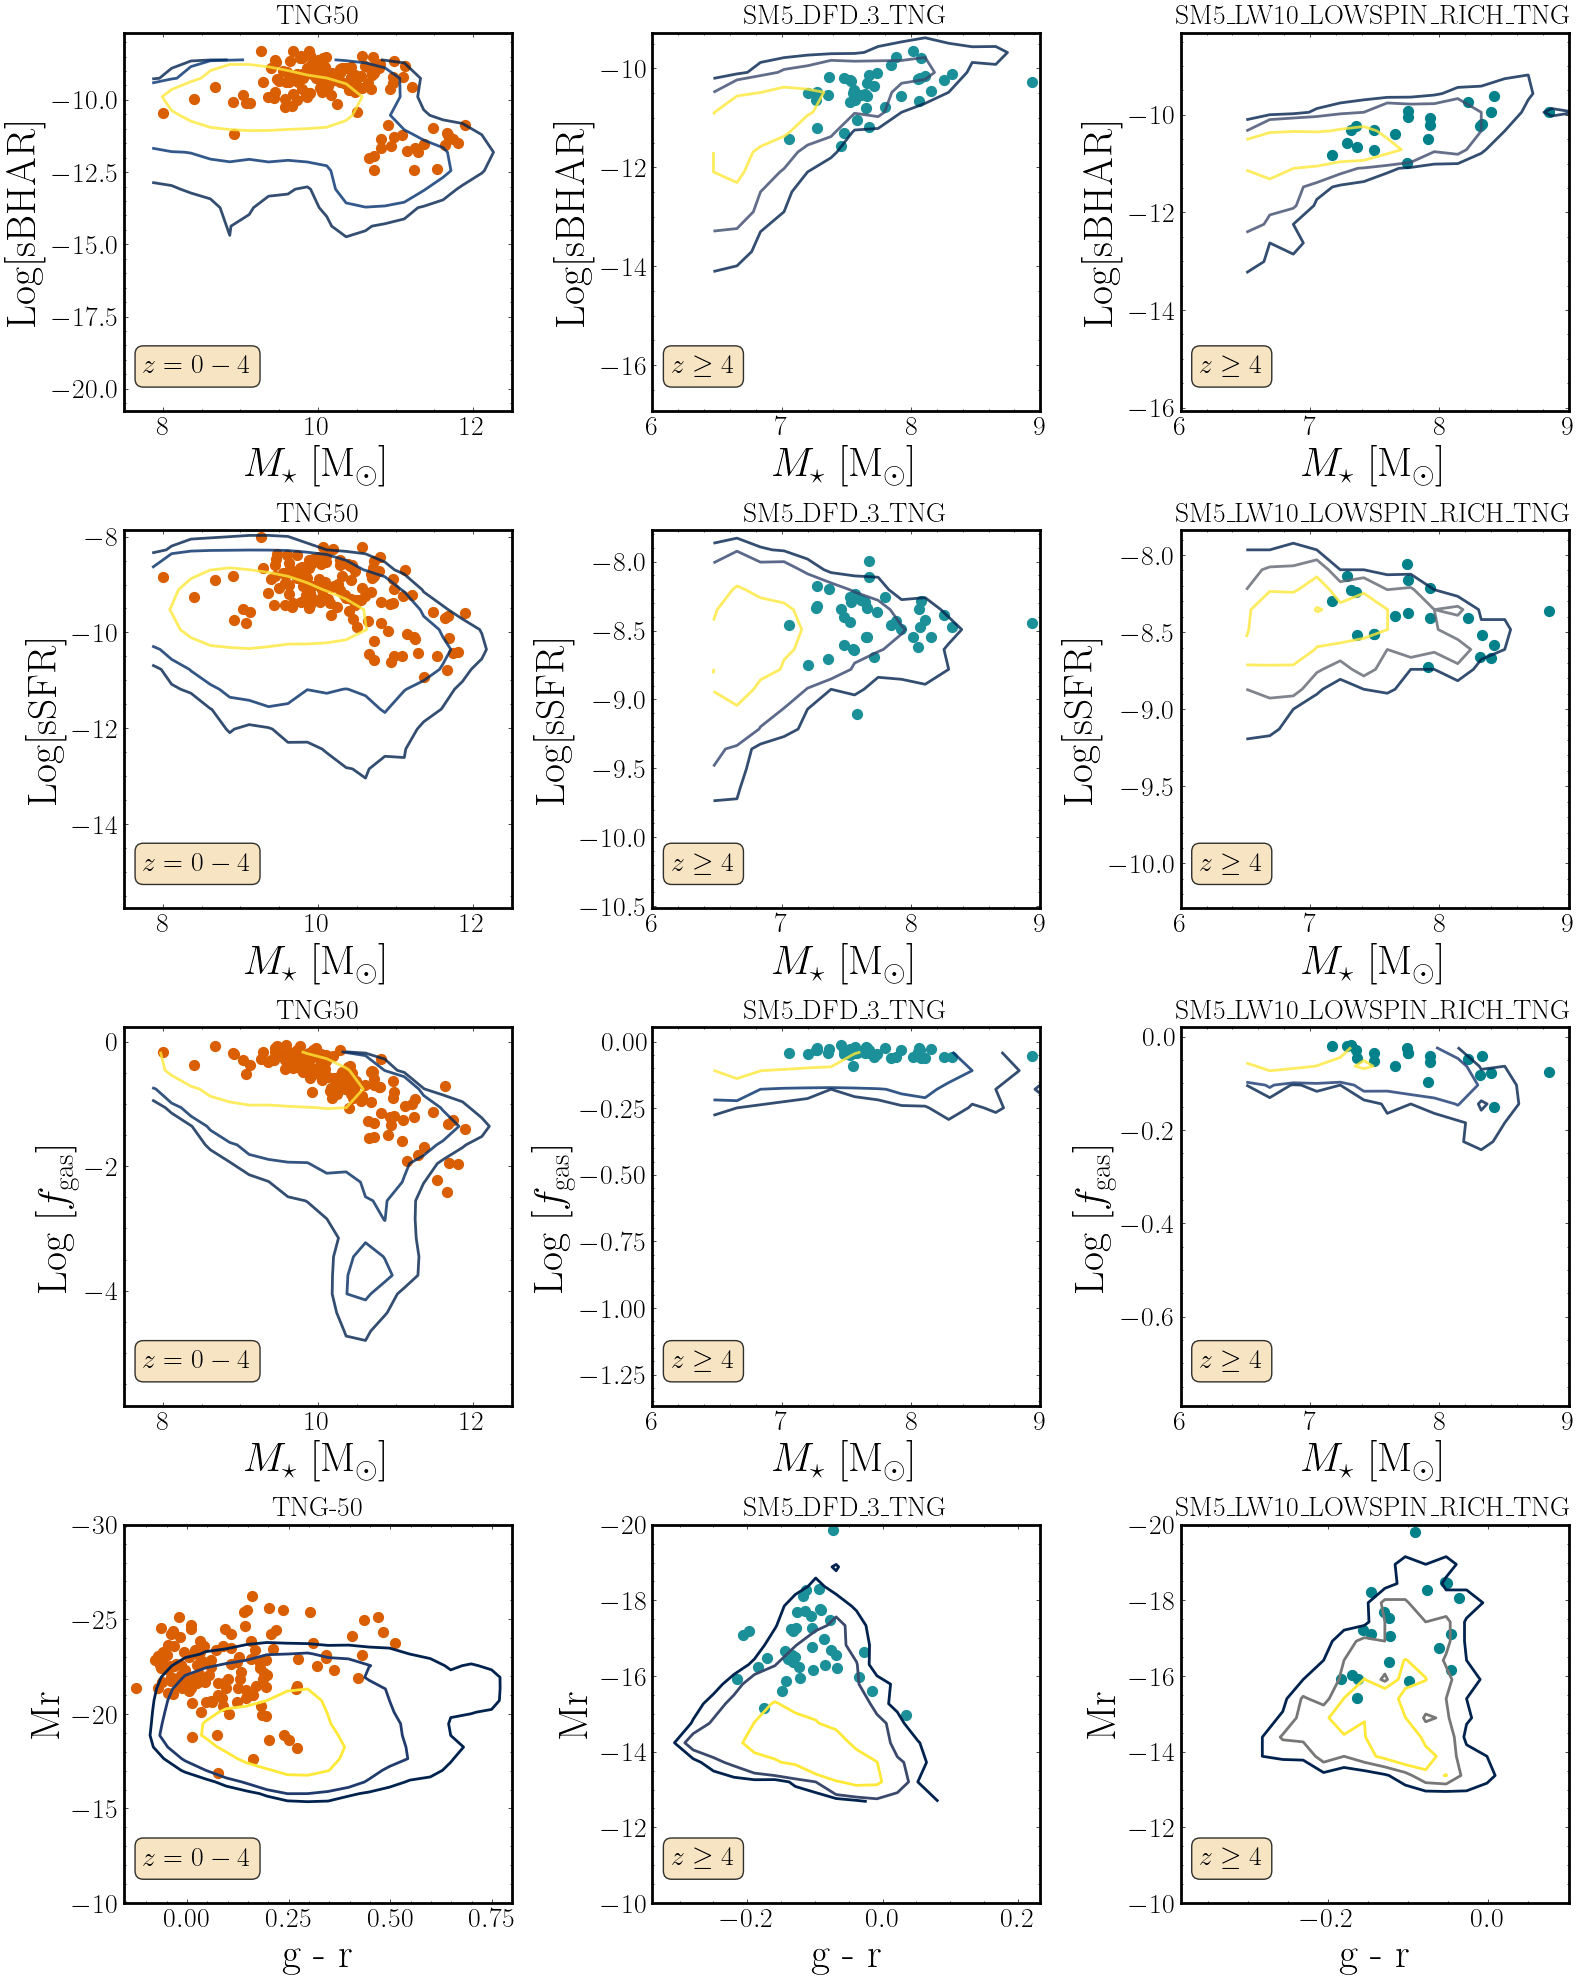

In [ ]:
fig,axes = plt.subplots(4,3,figsize=(16,20))
hostplot.set_plot_style(linewidth=2, titlesize=20,labelsize=30,xlabelsize=20,ylabelsize=20,legendsize=20)

quantities_list_subhalos = ['sBHAR','sSFR','fgas']
quantities_list_mergers = ['sBHAR_merging_pop','sSFR_merging_pop','fgas_post_merger']
quantities_labels = ['Log[sBHAR]','Log[sSFR]',r'Log [$f_{\rm gas}$]',r'Log[$R_{1/2}$ (kpc)]']
# quantities_list = ['sBHAR_merging_pop','Mdot_merging_pop','MBH_merging_pop','MgasInRad','fgas_progs','SFR_merging_pop','sSFR_merging_pop','Mstar_merging_pop']
# quantities_labels = ['Log[sBHAR]','Log[BHAR]',r'Log[$M_{\rm BH}$]',r'Log [$M_{\rm gas}$]',r'Log [$f_{\rm gas}$]','Log[SFR]','Log[sSFR]','Log[$M_{\star}$]']  

z_lower =0
z_upper =4

for i,quantities in enumerate(quantities_list_subhalos):
    print(f"Plotting {quantities} for subhalos and mergers...")
    ax1 = plot_property_vs_Mstar_for_z_interval_for_all_subhalos(axes[i,0],all_subhalos_objs['TNG50'], 'TNG50','#dfc27d', z_lower, z_upper, quantity_name=quantities, plot_log10=True,alpha=0.8)
    ax2 = plot_property_vs_Mstar_for_z_interval(axes[i,0],all_sim_objs['TNG50'],'TNG50',sim_colors['TNG50'],z_lower,z_upper,quantity_name=quantities_list_mergers[i]
                                            ,plot_log10=True,major_merger_mask=False,major_major_merger_mask=True,marker='o',size=50,alpha=1)
    ax1.set_ylabel(quantities_labels[i])
    ax1.set_title('TNG50')
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax1.text(0.05, 0.15, fr'$z = {z_lower}-{z_upper}$', transform=ax1.transAxes, fontsize=20, verticalalignment='top', bbox=props, weight='bold')
    ax1.set_xlim(7.5,12.5)
    

z_lower =4
z_upper =12

for i,quantities in enumerate(quantities_list_subhalos):
    ax1 = plot_property_vs_Mstar_for_z_interval_for_all_subhalos(axes[i,1],all_subhalos_objs['SM5_DFD_3_TNG'], 'SM5_DFD_3_TNG','#dfc27d', z_lower, z_upper, quantity_name=quantities, plot_log10=True,alpha=0.8)
    ax2 = plot_property_vs_Mstar_for_z_interval(axes[i,1],all_sim_objs['SM5_DFD_3_TNG'],'SM5_DFD_3_TNG',sim_colors['SM5_DFD_3_TNG'],z_lower,z_upper,quantity_name=quantities_list_mergers[i]
                                            ,plot_log10=True,major_merger_mask=False,major_major_merger_mask=True,marker='o',size=50,alpha=1)
    ax1.set_ylabel(quantities_labels[i])
    ax1.set_title('SM5_DFD_3_TNG')
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax1.text(0.05, 0.15, fr'$z \geq {z_lower}$', transform=ax1.transAxes, fontsize=20, verticalalignment='top', bbox=props, weight='bold')
    ax1.set_xlim(6,9)

    

z_lower =4
z_upper =12

for i,quantities in enumerate(quantities_list_subhalos):
    ax1 = plot_property_vs_Mstar_for_z_interval_for_all_subhalos(axes[i,2],all_subhalos_objs['SM5_LW10_LOWSPIN_RICH_TNG'], 'SM5_LW10_LOWSPIN_RICH_TNG','#dfc27d', z_lower, z_upper, quantity_name=quantities, plot_log10=True,alpha=0.8)
    ax2 = plot_property_vs_Mstar_for_z_interval(axes[i,2],all_sim_objs['SM5_LW10_LOWSPIN_RICH_TNG'],'SM5_LW10_LOWSPIN_RICH_TNG',sim_colors['SM5_LW10_LOWSPIN_RICH_TNG'],z_lower,z_upper,quantity_name=quantities_list_mergers[i]
                                            ,plot_log10=True,major_merger_mask=False,major_major_merger_mask=True,marker='o',size=50,alpha=1)
    ax1.set_ylabel(quantities_labels[i])
    ax1.set_title('SM5_LW10_LOWSPIN_RICH_TNG')
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax1.text(0.05, 0.15, fr'$z \geq {z_lower}$', transform=ax1.transAxes, fontsize=20, verticalalignment='top', bbox=props, weight='bold')
    ax1.set_xlim(6,9)


z_lower =0
z_upper =4

ax = plot_color_magnitude_diagram(axes[3,0],all_subhalos_objs['TNG50'],z_lower=z_lower,z_upper=z_upper,plot_name='All',sim_color='#dfc27d',scatter=False,all_subhalos=True,contours=True,sim_size=50)
ax = plot_color_magnitude_diagram(axes[3,0],all_sim_objs['TNG50'],z_lower=z_lower,z_upper=z_upper,plot_name='Mergers',sim_color=TNG_color,scatter=True,all_subhalos=False,contours=False,sim_size=50)
ax.set_title('TNG-50')
ax.set_xlabel('g - r')
ax.set_ylabel('Mr')
ax.set_ylim(-30, -10)
ax.invert_yaxis()
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.15, fr'$z = {z_lower}-{z_upper}$', transform=ax.transAxes, fontsize=20, verticalalignment='top', bbox=props, weight='bold')
# ax.set_xlim(7.5,12.5)
    
# ax.legend(loc="lower left")
# ax.set_xlim(-0.5,1)

z_lower =4
z_upper =12


ax = plot_color_magnitude_diagram(axes[3,1],all_subhalos_objs['SM5_DFD_3_TNG'],z_lower=z_lower,z_upper=z_upper,plot_name='All',sim_color='#dfc27d',scatter=False,all_subhalos=True,contours=True,sim_size=50)
ax = plot_color_magnitude_diagram(axes[3,1],all_sim_objs['SM5_DFD_3_TNG'],z_lower=z_lower,z_upper=z_upper,plot_name='Mergers',sim_color=sim_colors['SM5_DFD_3_TNG'],scatter=True,all_subhalos=False,contours=False,sim_size=50)
ax.set_title('SM5_DFD_3_TNG')
ax.set_xlabel('g - r')
ax.set_ylabel('Mr')
ax.set_ylim(-20, -10)
ax.invert_yaxis()
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.15, fr'$z \geq {z_lower}$', transform=ax.transAxes, fontsize=20, verticalalignment='top', bbox=props, weight='bold')


ax = plot_color_magnitude_diagram(axes[3,2],all_subhalos_objs['SM5_LW10_LOWSPIN_RICH_TNG'],z_lower=z_lower,z_upper=z_upper,plot_name='All',sim_color='#dfc27d',scatter=False,all_subhalos=True,contours=True,sim_size=50)
ax = plot_color_magnitude_diagram(axes[3,2],all_sim_objs['SM5_LW10_LOWSPIN_RICH_TNG'],z_lower=z_lower,z_upper=z_upper,plot_name='Mergers',sim_color=sim_colors['SM5_LW10_LOWSPIN_RICH_TNG'],scatter=True,all_subhalos=False,contours=False,sim_size=50)
ax.set_title('SM5_LW10_LOWSPIN_RICH_TNG')
ax.set_xlabel('g - r')
ax.set_ylabel('Mr')
ax.set_ylim(-20, -10)
ax.invert_yaxis()
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.15, fr'$z \geq {z_lower}$', transform=ax.transAxes, fontsize=20, verticalalignment='top', bbox=props, weight='bold')



fig.tight_layout()
fig.savefig('../../figures/merging_population_compared_to_other_subhalos.pdf')

In [170]:
def compute_hellinger_by_mstar_bins(sim_name, sim_obj, all_subhalos_obj, z_lower, z_upper, 
                                    quantity_name, quantities_list_mergers, mstar_bins=np.array([6, 7, 8, 9, 10, 11, 12])):
    """
    Compute Hellinger distance for a quantity within Mstar bins
    """
    
    # Get merger data
    z_mask_merger = (sim_obj.z_merging_pop >= z_lower) & (sim_obj.z_merging_pop < z_upper)
    merger_mstar = np.log10(sim_obj.Mstar_merging_pop[z_mask_merger])
    
    if quantity_name == "sBHAR":
        merger_property = np.log10(sim_obj.sBHAR_merging_pop[z_mask_merger])
    elif quantity_name == "sSFR":
        merger_property = np.log10(sim_obj.sSFR_merging_pop[z_mask_merger])
    elif quantity_name == "fgas":
        merger_property = np.log10(sim_obj.fgas_post_merger[z_mask_merger])
    
    # Get all-subhalos data
    z_mask_all = (all_subhalos_obj['z'][:] >= z_lower) & (all_subhalos_obj['z'][:] < z_upper)
    all_mstar = np.log10(all_subhalos_obj['Mstar'][z_mask_all])
    
    if quantity_name == "sBHAR":
        all_property = np.log10(all_subhalos_obj['MdotBH'][z_mask_all] / all_subhalos_obj['MBH'][z_mask_all])
    elif quantity_name == "sSFR":
        all_property = np.log10(all_subhalos_obj['SFR'][z_mask_all] / all_subhalos_obj['Mstar'][z_mask_all])
    elif quantity_name == "fgas":
        all_property = np.log10(all_subhalos_obj['MgasinRad'][z_mask_all] / 
                                (all_subhalos_obj['MgasinRad'][z_mask_all] + all_subhalos_obj['Mstar'][z_mask_all]))
    
    # Filter out infinities and NaNs
    valid_merger = np.isfinite(merger_mstar) & np.isfinite(merger_property)
    valid_all = np.isfinite(all_mstar) & np.isfinite(all_property)
    
    merger_mstar = merger_mstar[valid_merger]
    merger_property = merger_property[valid_merger]
    all_mstar = all_mstar[valid_all]
    all_property = all_property[valid_all]
    
    # Compute Hellinger distance within Mstar bins
    print(f"\n{'='*90}")
    print(f"Simulation: {sim_name} | Quantity: {quantity_name} | z = {z_lower}-{z_upper}")
    print(f"{'='*90}")
    print(f"{'Mstar Bin':<15} {'Hellinger Dist':<18} {'N_merger':<12} {'N_all':<12}")
    print(f"{'-'*90}")
    
    results = []
    
    for i in range(len(mstar_bins)-1):
        mask_merger = (merger_mstar >= mstar_bins[i]) & (merger_mstar < mstar_bins[i+1])
        mask_all = (all_mstar >= mstar_bins[i]) & (all_mstar < mstar_bins[i+1])
        
        n_merger = np.sum(mask_merger)
        n_all = np.sum(mask_all)
        
        if n_merger > 1 and n_all > 1:  # Need at least 2 samples
            hd = hostutils.hellinger_distance(merger_property[mask_merger], all_property[mask_all], bins=30)
            print(f"{mstar_bins[i]:.1f}-{mstar_bins[i+1]:.1f}      {hd:<18.4f} {n_merger:<12} {n_all:<12}")
            results.append({
                'mstar_bin': f"{mstar_bins[i]:.1f}-{mstar_bins[i+1]:.1f}",
                'hellinger_dist': hd,
                'n_merger': n_merger,
                'n_all': n_all
            })
        else:
            print(f"{mstar_bins[i]:.1f}-{mstar_bins[i+1]:.1f}      {'N/A':<18} {n_merger:<12} {n_all:<12}")
    
    return results

# Run for all three simulations and quantities
quantities = ['sBHAR', 'sSFR', 'fgas']
mstar_bins = np.array([6, 7, 8, 9, 10, 11, 12])

# TNG50
print("\n" + "="*90)
print("TNG50 (z=0-5)")
print("="*90)
for qty in quantities:
    compute_hellinger_by_mstar_bins('TNG50', all_sim_objs['TNG50'], all_subhalos_objs['TNG50'], 
                                    0, 5, qty, quantities, mstar_bins)

# SM5_DFD_3_TNG
print("\n" + "="*90)
print("SM5_DFD_3_TNG (z=5-12)")
print("="*90)
for qty in quantities:
    compute_hellinger_by_mstar_bins('SM5_DFD_3_TNG', all_sim_objs['SM5_DFD_3_TNG'], all_subhalos_objs['SM5_DFD_3_TNG'], 
                                    5, 12, qty, quantities, mstar_bins)

# SM5_LW10_LOWSPIN_RICH_TNG
print("\n" + "="*90)
print("SM5_LW10_LOWSPIN_RICH_TNG (z=5-12)")
print("="*90)
for qty in quantities:
    compute_hellinger_by_mstar_bins('SM5_LW10_LOWSPIN_RICH_TNG', all_sim_objs['SM5_LW10_LOWSPIN_RICH_TNG'], 
                                    all_subhalos_objs['SM5_LW10_LOWSPIN_RICH_TNG'], 
                                    5, 12, qty, quantities, mstar_bins)


TNG50 (z=0-5)

Simulation: TNG50 | Quantity: sBHAR | z = 0-5
Mstar Bin       Hellinger Dist     N_merger     N_all       
------------------------------------------------------------------------------------------
6.0-7.0      N/A                0            0           
7.0-8.0      N/A                1            3206        
8.0-9.0      0.3275             6            106674      
9.0-10.0      0.3921             130          116083      
10.0-11.0      0.4199             246          45342       
11.0-12.0      0.3794             85           6374        

Simulation: TNG50 | Quantity: sSFR | z = 0-5
Mstar Bin       Hellinger Dist     N_merger     N_all       
------------------------------------------------------------------------------------------
6.0-7.0      N/A                0            0           
7.0-8.0      N/A                1            3183        
8.0-9.0      0.6649             6            106441      
9.0-10.0      0.4413             130          115900      
10

/tmp/ipykernel_4101181/3855945360.py:25: RuntimeWarning: divide by zero encountered in log10
  all_property = np.log10(all_subhalos_obj['SFR'][z_mask_all] / all_subhalos_obj['Mstar'][z_mask_all])
/tmp/ipykernel_4101181/3855945360.py:27: RuntimeWarning: divide by zero encountered in log10
  all_property = np.log10(all_subhalos_obj['MgasinRad'][z_mask_all] /


/tmp/ipykernel_4101181/1088981742.py:26: RuntimeWarning: divide by zero encountered in log10
  all_property = np.log10(all_subhalos_obj['SFR'][z_mask_all] / all_subhalos_obj['Mstar'][z_mask_all])
/tmp/ipykernel_4101181/1088981742.py:28: RuntimeWarning: divide by zero encountered in log10
  all_property = np.log10(all_subhalos_obj['MgasinRad'][z_mask_all] /


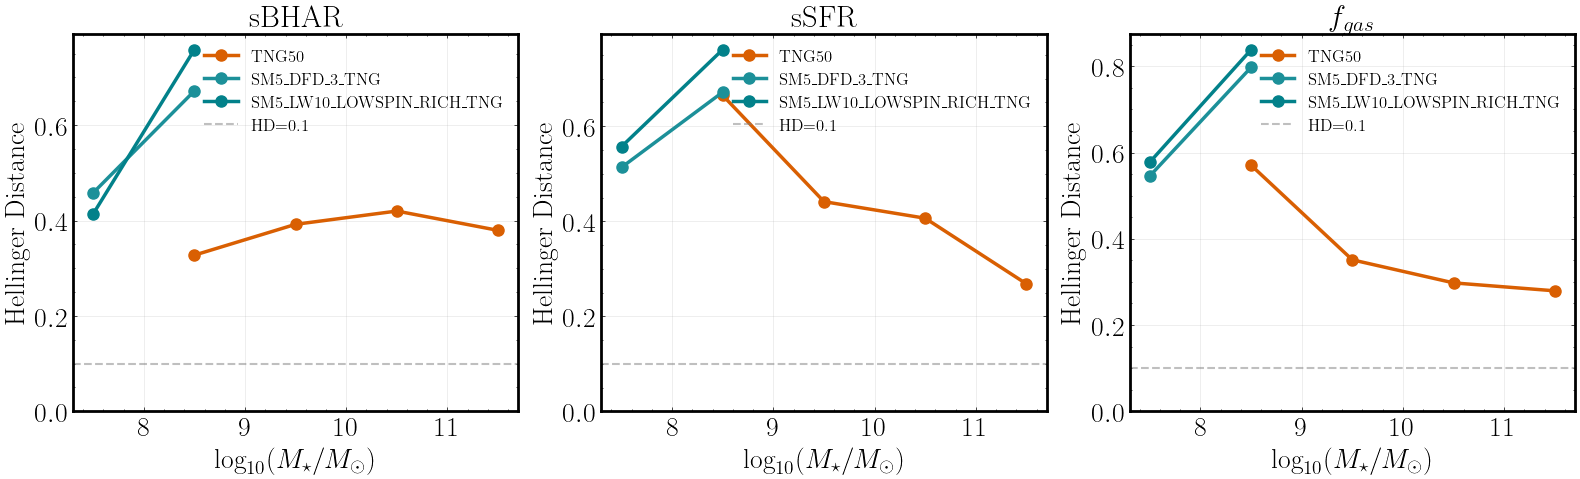

In [156]:
def compute_hellinger_vs_mstar(sim_name, sim_obj, all_subhalos_obj, z_lower, z_upper, 
                               quantity_name, mstar_bins=np.array([6, 7, 8, 9, 10, 11, 12])):
    """
    Compute Hellinger distance for a quantity across Mstar bins
    Returns arrays of Mstar bin centers and Hellinger distances
    """
    
    # Get merger data
    z_mask_merger = (sim_obj.z_merging_pop >= z_lower) & (sim_obj.z_merging_pop < z_upper)
    merger_mstar = np.log10(sim_obj.Mstar_merging_pop[z_mask_merger])
    
    if quantity_name == "sBHAR":
        merger_property = np.log10(sim_obj.sBHAR_merging_pop[z_mask_merger])
    elif quantity_name == "sSFR":
        merger_property = np.log10(sim_obj.sSFR_merging_pop[z_mask_merger])
    elif quantity_name == "fgas":
        merger_property = np.log10(sim_obj.fgas_post_merger[z_mask_merger])
    
    # Get all-subhalos data
    z_mask_all = (all_subhalos_obj['z'][:] >= z_lower) & (all_subhalos_obj['z'][:] < z_upper)
    all_mstar = np.log10(all_subhalos_obj['Mstar'][z_mask_all])
    
    if quantity_name == "sBHAR":
        all_property = np.log10(all_subhalos_obj['MdotBH'][z_mask_all] / all_subhalos_obj['MBH'][z_mask_all])
    elif quantity_name == "sSFR":
        all_property = np.log10(all_subhalos_obj['SFR'][z_mask_all] / all_subhalos_obj['Mstar'][z_mask_all])
    elif quantity_name == "fgas":
        all_property = np.log10(all_subhalos_obj['MgasinRad'][z_mask_all] / 
                                (all_subhalos_obj['MgasinRad'][z_mask_all] + all_subhalos_obj['Mstar'][z_mask_all]))
    
    # Filter out infinities and NaNs
    valid_merger = np.isfinite(merger_mstar) & np.isfinite(merger_property)
    valid_all = np.isfinite(all_mstar) & np.isfinite(all_property)
    
    merger_mstar = merger_mstar[valid_merger]
    merger_property = merger_property[valid_merger]
    all_mstar = all_mstar[valid_all]
    all_property = all_property[valid_all]
    
    # Compute Hellinger distance within Mstar bins
    mstar_centers = []
    hd_values = []
    
    for i in range(len(mstar_bins)-1):
        mask_merger = (merger_mstar >= mstar_bins[i]) & (merger_mstar < mstar_bins[i+1])
        mask_all = (all_mstar >= mstar_bins[i]) & (all_mstar < mstar_bins[i+1])
        
        n_merger = np.sum(mask_merger)
        n_all = np.sum(mask_all)
        
        if n_merger > 1 and n_all > 1:
            hd = hostutils.hellinger_distance(merger_property[mask_merger], all_property[mask_all], bins=30)
            mstar_centers.append((mstar_bins[i] + mstar_bins[i+1]) / 2)
            hd_values.append(hd)
    
    return np.array(mstar_centers), np.array(hd_values)

# Create visualization
hostplot.set_plot_style(linewidth=2, titlesize=20, labelsize=25, xlabelsize=20, ylabelsize=20, legendsize=15)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

quantities = ['sBHAR', 'sSFR', 'fgas']
quantity_labels = ['sBHAR', 'sSFR', r'$f_{gas}$']
mstar_bins = np.array([6, 7, 8, 9, 10, 11, 12])

sim_configs = [
    ('TNG50', all_sim_objs['TNG50'], all_subhalos_objs['TNG50'], 0, 5, sim_colors['TNG50']),
    ('SM5_DFD_3_TNG', all_sim_objs['SM5_DFD_3_TNG'], all_subhalos_objs['SM5_DFD_3_TNG'], 5, 12, sim_colors['SM5_DFD_3_TNG']),
    ('SM5_LW10_LOWSPIN_RICH_TNG', all_sim_objs['SM5_LW10_LOWSPIN_RICH_TNG'], all_subhalos_objs['SM5_LW10_LOWSPIN_RICH_TNG'], 5, 12, sim_colors['SM5_LW10_LOWSPIN_RICH_TNG'])
]

for ax_idx, qty in enumerate(quantities):
    ax = axes[ax_idx]
    
    for sim_name, sim_obj, all_subhalos_obj, z_lower, z_upper, color in sim_configs:
        mstar_centers, hd_vals = compute_hellinger_vs_mstar(sim_name, sim_obj, all_subhalos_obj, 
                                                            z_lower, z_upper, qty, mstar_bins)
        
        ax.plot(mstar_centers, hd_vals, marker='o', label=sim_name, color=color, linewidth=2.5, markersize=8)
    
    ax.set_xlabel(r'$\log_{10}(M_{\star}/M_{\odot})$', fontsize=20)
    ax.set_ylabel('Hellinger Distance', fontsize=20)
    ax.set_title(quantity_labels[ax_idx], fontsize=22, weight='bold')
    ax.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, linewidth=1.5, label='HD=0.1')
    ax.legend(fontsize=12, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, max([0.35, ax.get_ylim()[1]])])

fig.tight_layout()
#fig.savefig('../../figures/hellinger_distance_vs_mstar.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [157]:
def compute_hellinger_by_mstar_bins(sim_name, sim_obj, all_subhalos_obj, z_lower, z_upper, 
                                    quantity_name, quantities_list_mergers, mstar_bins=np.array([6, 7, 8, 9, 10, 11, 12])):
    """
    Compute Hellinger distance for a quantity within Mstar bins
    """
    
    # Get merger data
    z_mask_merger = (sim_obj.z_merging_pop >= z_lower) & (sim_obj.z_merging_pop < z_upper)
    merger_mstar = np.log10(sim_obj.Mstar_merging_pop[z_mask_merger])
    
    if quantity_name == "sBHAR":
        merger_property = np.log10(sim_obj.sBHAR_merging_pop[z_mask_merger])
    elif quantity_name == "sSFR":
        merger_property = np.log10(sim_obj.sSFR_merging_pop[z_mask_merger])
    elif quantity_name == "fgas":
        merger_property = np.log10(sim_obj.fgas_post_merger[z_mask_merger])
    
    # Get all-subhalos data
    z_mask_all = (all_subhalos_obj['z'][:] >= z_lower) & (all_subhalos_obj['z'][:] < z_upper)
    all_mstar = np.log10(all_subhalos_obj['Mstar'][z_mask_all])
    
    if quantity_name == "sBHAR":
        all_property = np.log10(all_subhalos_obj['MdotBH'][z_mask_all] / all_subhalos_obj['MBH'][z_mask_all])
    elif quantity_name == "sSFR":
        all_property = np.log10(all_subhalos_obj['SFR'][z_mask_all] / all_subhalos_obj['Mstar'][z_mask_all])
    elif quantity_name == "fgas":
        all_property = np.log10(all_subhalos_obj['MgasinRad'][z_mask_all] / 
                                (all_subhalos_obj['MgasinRad'][z_mask_all] + all_subhalos_obj['Mstar'][z_mask_all]))
    
    # Filter out infinities and NaNs
    valid_merger = np.isfinite(merger_mstar) & np.isfinite(merger_property)
    valid_all = np.isfinite(all_mstar) & np.isfinite(all_property)
    
    merger_mstar = merger_mstar[valid_merger]
    merger_property = merger_property[valid_merger]
    all_mstar = all_mstar[valid_all]
    all_property = all_property[valid_all]
    
    # Compute Hellinger distance within Mstar bins
    print(f"\n{'='*90}")
    print(f"Simulation: {sim_name} | Quantity: {quantity_name} | z = {z_lower}-{z_upper}")
    print(f"{'='*90}")
    print(f"{'Mstar Bin':<15} {'Hellinger Dist':<18} {'N_merger':<12} {'N_all':<12}")
    print(f"{'-'*90}")
    
    results = []
    hd_values = []
    
    for i in range(len(mstar_bins)-1):
        mask_merger = (merger_mstar >= mstar_bins[i]) & (merger_mstar < mstar_bins[i+1])
        mask_all = (all_mstar >= mstar_bins[i]) & (all_mstar < mstar_bins[i+1])
        
        n_merger = np.sum(mask_merger)
        n_all = np.sum(mask_all)
        
        if n_merger > 1 and n_all > 1:  # Need at least 2 samples
            hd = hostutils.hellinger_distance(merger_property[mask_merger], all_property[mask_all], bins=30)
            hd_values.append(hd)
            print(f"{mstar_bins[i]:.1f}-{mstar_bins[i+1]:.1f}      {hd:<18.4f} {n_merger:<12} {n_all:<12}")
            results.append({
                'mstar_bin': f"{mstar_bins[i]:.1f}-{mstar_bins[i+1]:.1f}",
                'hellinger_dist': hd,
                'n_merger': n_merger,
                'n_all': n_all
            })
        else:
            print(f"{mstar_bins[i]:.1f}-{mstar_bins[i+1]:.1f}      {'N/A':<18} {n_merger:<12} {n_all:<12}")
    
    # Print average Hellinger distance
    if hd_values:
        avg_hd = np.mean(hd_values)
        print(f"{'-'*90}")
        print(f"{'Average Hellinger Distance:':<33} {avg_hd:.4f}")
        print(f"{'='*90}\n")
    
    return results

# Run for all three simulations and quantities
quantities = ['sBHAR', 'sSFR', 'fgas']
mstar_bins = np.array([6, 7, 8, 9, 10, 11, 12])

# TNG50
print("\n" + "="*90)
print("TNG50 (z=0-5)")
print("="*90)
for qty in quantities:
    compute_hellinger_by_mstar_bins('TNG50', all_sim_objs['TNG50'], all_subhalos_objs['TNG50'], 
                                    0, 5, qty, quantities, mstar_bins)

# SM5_DFD_3_TNG
print("\n" + "="*90)
print("SM5_DFD_3_TNG (z=5-12)")
print("="*90)
for qty in quantities:
    compute_hellinger_by_mstar_bins('SM5_DFD_3_TNG', all_sim_objs['SM5_DFD_3_TNG'], all_subhalos_objs['SM5_DFD_3_TNG'], 
                                    5, 12, qty, quantities, mstar_bins)

# SM5_LW10_LOWSPIN_RICH_TNG
print("\n" + "="*90)
print("SM5_LW10_LOWSPIN_RICH_TNG (z=5-12)")
print("="*90)
for qty in quantities:
    compute_hellinger_by_mstar_bins('SM5_LW10_LOWSPIN_RICH_TNG', all_sim_objs['SM5_LW10_LOWSPIN_RICH_TNG'], 
                                    all_subhalos_objs['SM5_LW10_LOWSPIN_RICH_TNG'], 
                                    5, 12, qty, quantities, mstar_bins)


TNG50 (z=0-5)

Simulation: TNG50 | Quantity: sBHAR | z = 0-5
Mstar Bin       Hellinger Dist     N_merger     N_all       
------------------------------------------------------------------------------------------
6.0-7.0      N/A                0            0           
7.0-8.0      N/A                1            3206        
8.0-9.0      0.3275             6            106674      
9.0-10.0      0.3921             130          116083      
10.0-11.0      0.4199             246          45342       
11.0-12.0      0.3794             85           6374        
------------------------------------------------------------------------------------------
Average Hellinger Distance:       0.3797


Simulation: TNG50 | Quantity: sSFR | z = 0-5
Mstar Bin       Hellinger Dist     N_merger     N_all       
------------------------------------------------------------------------------------------
6.0-7.0      N/A                0            0           
7.0-8.0      N/A                1           

/tmp/ipykernel_4101181/790780386.py:25: RuntimeWarning: divide by zero encountered in log10
  all_property = np.log10(all_subhalos_obj['SFR'][z_mask_all] / all_subhalos_obj['Mstar'][z_mask_all])
/tmp/ipykernel_4101181/790780386.py:27: RuntimeWarning: divide by zero encountered in log10
  all_property = np.log10(all_subhalos_obj['MgasinRad'][z_mask_all] /
